In [ ]:
import os
import random
import numpy as np
from PIL import ImageFile

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import ImageFolder

from torch.utils.data import ( DataLoader,random_split)
from torchvision.datasets import ImageFolder
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
from tqdm import tqdm
from PIL import Image


# CONFIG
DATA_DIR = r"C:\Users\Komal\OneDrive\Desktop\plant_disease\data\New folder\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train"
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 0.001
VALID_SPLIT = 0.2
SEED = 42
MODEL_PATH = "cnn_cplant_classifiers.pth"
# FIX BROKEN IMAGES

ImageFile.LOAD_TRUNCATED_IMAGES = True
# REPRODUCIBILITY
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device(
    "cpu"
)

print("\nDevice:", device)

# TRANSFORMS

train_transform = transforms.Compose([
    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(

        [0.485,0.456,0.406],

        [0.229,0.224,0.225]

    )

])


val_transform = transforms.Compose([

    transforms.Resize(

        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        [0.485,0.456,0.406],

        [0.229,0.224,0.225]

    )

])
# REMOVE MISSING FILES

valid=[]
for path,label in dataset.samples:
    if os.path.exists(path):
        valid.append( (path,label))
    dataset.samples = valid
    dataset.targets = [
    x[1]
    for x in valid
]

print("Valid Images:",len(dataset))

# DATASET

class SafeImageFolder(
    ImageFolder
):

    def __getitem__(self, index):

        while True:

            try:

                return super().__getitem__(index)
            except (FileNotFoundError,OSError):

                index = random.randint(0,len(self.samples)-1)

dataset = SafeImageFolder(root=DATA_DIR,transform=train_transform)

print(
    "Dataset Loaded:",
    len(dataset)
)


# Reduce size for CPU

subset_size = min(
    10000,
    len(dataset)
)

indices = np.random.choice(
    len(dataset),
    subset_size,
    replace=False
)

dataset.samples = [
    dataset.samples[i]
    for i in indices
]

# SPLIT

val_size = int(
    VALID_SPLIT *
    len(dataset)
)

train_size = (

    len(dataset)

    -

    val_size
)

train_ds, val_ds = random_split(

    dataset,

    [

        train_size,

        val_size

    ],

    generator=torch.Generator().manual_seed(
        SEED
    )

)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

dataset.transform = val_transform

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)
# MODEL
class CNN(
    nn.Module
):
    def __init__(self,num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d( 3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(),
            nn.Linear(2048,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,num_classes)
        )
    def forward(self,x ):
        return self.net( x)

model = CNN(len(dataset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=LR)

# EVALUATE
def evaluate():
    model.eval()
    preds=[]
    labels=[]
    with torch.no_grad():
        for x,y in val_loader:
            out=model(x)
            pred=out.argmax(1)
            preds.extend(
                pred.numpy()
            )
            labels.extend(
                y.numpy()
            )
    acc=accuracy_score(
        labels,
        preds
    )
    pre=precision_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )
    rec=recall_score(
        labels,
        preds,
        average="weighted"
    )
    f1=f1_score(
        labels,
        preds,
        average="weighted"
    )

    return acc,pre,rec,f1

# TRAIN
best=0
for epoch in range( NUM_EPOCHS):
    model.train()
    total_loss=0
    loop=tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}"
    )

    for x,y in loop:
        optimizer.zero_grad()
        out=model(x)
        loss=criterion(
            out,
            y
        )
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
    acc,pre,rec,f1=evaluate()

    print(
f"""
Epoch:
{epoch+1}
Loss:
{total_loss:.2f}
Accuracy:
{acc:.4f}
Precision:
{pre:.4f}
Recall:
{rec:.4f}
F1:
{f1:.4f}
"""
)
    if acc>best:
        best=acc
        torch.save(
            {
                "model":
                model.state_dict(),

                "classes":
                dataset.classes

            },

            MODEL_PATH

        )


print(
"\nTraining Complete"
)

print(
"Best Accuracy:",
best
)


Device: cpu
Valid Images: 9920
Dataset Loaded: 70295


Epoch 1: 100%|██████████| 250/250 [01:19<00:00,  3.14it/s]



Epoch:
1
Loss:
723.70
Accuracy:
0.4565
Precision:
0.4664
Recall:
0.4565
F1:
0.4128



Epoch 2: 100%|██████████| 250/250 [01:16<00:00,  3.26it/s]



Epoch:
2
Loss:
483.04
Accuracy:
0.5330
Precision:
0.5644
Recall:
0.5330
F1:
0.5137



...


Epoch:
13
Loss:
171.83
Accuracy:
0.7930
Precision:
0.8092
Recall:
0.7930
F1:
0.7934



Epoch 14: 100%|██████████| 250/250 [01:07<00:00,  3.68it/s]



Epoch:
14
Loss:
162.54
Accuracy:
0.8080
Precision:
0.8241
Recall:
0.8080
F1:
0.8071



Epoch 15: 100%|██████████| 250/250 [01:11<00:00,  3.51it/s]



Epoch:
15
Loss:
159.23
Accuracy:
0.8225
Precision:
0.8312
Recall:
0.8225
F1:
0.8212


Training Complete
Best Accuracy: 0.8225


In [9]:
# Recover number of classes
try:

    num_classes = len(
        train_loader.dataset.dataset.classes
    )

except:

    num_classes = len(
        full_dataset.classes
    )

print(
"num_classes =",
num_classes
)

num_classes = 38


In [10]:
from torchvision.models import resnet50
import torch.nn as nn
import torch.optim as optim


model = resnet50(
    weights="DEFAULT"
)

# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False


# Replace final layer
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

print("ResNet50 Loaded")

ResNet50 Loaded


In [11]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

def evaluate():
    model.eval()
    preds=[]
    labels=[]
    with torch.no_grad():
        for x,y in val_loader:
            x=x.to(device)
            y=y.to(device)
            out=model(x)
            pred=out.argmax(1)
            preds.extend(pred.cpu().numpy() )
            labels.extend(y.cpu().numpy())

    acc=accuracy_score( labels,preds)
    pre=precision_score(labels,preds,average="weighted",zero_division=0)
    rec=recall_score(labels,preds,average="weighted")
    f1=f1_score(labels,preds,average="weighted")
    return acc,pre,rec,f1

In [12]:
best=0
EPOCHS=10
for epoch in range(EPOCHS):
    model.train()
    total_loss=0
    for x,y in train_loader:
        x=x.to(device)
        y=y.to(device)
        optimizer.zero_grad()
        out=model(x)
        loss=criterion(out,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    acc,pre,rec,f1 = evaluate()
    
    print(f"""
Epoch {epoch+1}
Loss:
{total_loss:.2f}
Accuracy:
{acc:.4f}
Precision:
{pre:.4f}
Recall:
{rec:.4f}
F1:
{f1:.4f}
""")

    if acc>best:
        best=acc
        torch.save(
            model.state_dict(),
            "resnet50_plant.pth"
        )

print("\nBest Accuracy:",best)


Epoch 1
Loss:
797.85
Accuracy:
0.6130
Precision:
0.6781
Recall:
0.6130
F1:
0.6065


Epoch 2
Loss:
607.27
Accuracy:
0.7370
Precision:
0.7519
Recall:
0.7370
F1:
0.7280


Epoch 3
Loss:
477.96
Accuracy:
0.7725
Precision:
0.7804
Recall:
0.7725
F1:
0.7640


Epoch 4
Loss:
393.33
Accuracy:
0.7895
Precision:
0.7972
Recall:
0.7895
F1:
0.7822


Epoch 5
Loss:
331.80
Accuracy:
0.8080
Precision:
0.8171
Recall:
0.8080
F1:
0.8039


Epoch 6
Loss:
286.89
Accuracy:
0.8215
Precision:
0.8299
Recall:
0.8215
F1:
0.8171


Epoch 7
Loss:
252.64
Accuracy:
0.8380
Precision:
0.8418
Recall:
0.8380
F1:
0.8340


Epoch 8
Loss:
227.98
Accuracy:
0.8440
Precision:
0.8465
Recall:
0.8440
F1:
0.8408


Epoch 9
Loss:
205.03
Accuracy:
0.8505
Precision:
0.8563
Recall:
0.8505
F1:
0.8485


Epoch 10
Loss:
189.15
Accuracy:
0.8540
Precision:
0.8568
Recall:
0.8540
F1:
0.8516


Best Accuracy: 0.854


In [13]:
#MoblieNetV2
from torchvision.models import mobilenet_v2
import torch.nn as nn
import torch.optim as optim


model = mobilenet_v2(
    weights="DEFAULT"
)

for param in model.parameters():

    param.requires_grad=False


model.classifier[1]=nn.Linear(

    model.classifier[1].in_features,

    num_classes

)


model=model.to(device)
criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(

model.classifier.parameters(),

lr=0.0001

)

print("MobileNetV2 Ready")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\Komal/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:11<00:00, 1.25MB/s]


MobileNetV2 Ready


In [15]:
best=0
EPOCHS=10
for epoch in range(EPOCHS):
    model.train()
    total_loss=0
    for x,y in train_loader:
        x=x.to(device)
        y=y.to(device)
        optimizer.zero_grad()
        out=model(x)
        loss=criterion(
            out,
            y
        )
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()

    acc,pre,rec,f1=evaluate()

    print(
f"""
Epoch {epoch+1}
Loss:{total_loss:.2f}
Accuracy:{acc:.4f}
Precision:{pre:.4f}
Recall:{rec:.4f}
F1:{f1:.4f}
"""
)
    if acc>best:
        best=acc
        torch.save(
model.state_dict(),
"mobilenet_plant.pth"
)
print("\nBest Accuracy:",best)


Epoch 1
Loss:619.81
Accuracy:0.7610
Precision:0.7744
Recall:0.7610
F1:0.7529


Epoch 2
Loss:476.94
Accuracy:0.8185
Precision:0.8205
Recall:0.8185
F1:0.8122


Epoch 3
Loss:382.43
Accuracy:0.8325
Precision:0.8305
Recall:0.8325
F1:0.8260


Epoch 4
Loss:321.16
Accuracy:0.8370
Precision:0.8339
Recall:0.8370
F1:0.8307


Epoch 5
Loss:278.49
Accuracy:0.8475
Precision:0.8430
Recall:0.8475
F1:0.8410


Epoch 6
Loss:244.92
Accuracy:0.8550
Precision:0.8537
Recall:0.8550
F1:0.8506


Epoch 7
Loss:220.91
Accuracy:0.8635
Precision:0.8613
Recall:0.8635
F1:0.8589


Epoch 8
Loss:201.16
Accuracy:0.8675
Precision:0.8665
Recall:0.8675
F1:0.8645


Epoch 9
Loss:185.75
Accuracy:0.8680
Precision:0.8677
Recall:0.8680
F1:0.8655


Epoch 10
Loss:173.85
Accuracy:0.8740
Precision:0.8726
Recall:0.8740
F1:0.8705


Best Accuracy: 0.874


In [16]:
#EfficientNetBO
from torchvision.models import efficientnet_b0
import torch.nn as nn
import torch.optim as optim
model = efficientnet_b0(
    weights="DEFAULT"
)
for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.0001
)
print("EfficientNetB0 Ready")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Komal/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:25<00:00, 840kB/s] 

EfficientNetB0 Ready


In [17]:
best = 0
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    acc, pre, rec, f1 = evaluate()

    print(
f"""
Epoch {epoch+1}
Loss:{total_loss:.2f}
Accuracy:{acc:.4f}
Precision:{pre:.4f}
Recall:{rec:.4f}
F1:{f1:.4f}
"""
)

    if acc > best:
        best = acc
        torch.save(
            model.state_dict(),
            "efficientnetb0_plant.pth"
        )

print("\nBest Accuracy:",best)


Epoch 1
Loss:795.95
Accuracy:0.5585
Precision:0.5945
Recall:0.5585
F1:0.5457


Epoch 2
Loss:604.79
Accuracy:0.7155
Precision:0.7315
Recall:0.7155
F1:0.7051


Epoch 3
Loss:478.68
Accuracy:0.7545
Precision:0.7629
Recall:0.7545
F1:0.7469


Epoch 4
Loss:394.03
Accuracy:0.7865
Precision:0.7904
Recall:0.7865
F1:0.7804


Epoch 5
Loss:332.67
Accuracy:0.8105
Precision:0.8135
Recall:0.8105
F1:0.8054


Epoch 6
Loss:292.97
Accuracy:0.8160
Precision:0.8186
Recall:0.8160
F1:0.8118


Epoch 7
Loss:263.30
Accuracy:0.8235
Precision:0.8257
Recall:0.8235
F1:0.8202


Epoch 8
Loss:238.85
Accuracy:0.8305
Precision:0.8310
Recall:0.8305
F1:0.8261


Epoch 9
Loss:220.62
Accuracy:0.8355
Precision:0.8356
Recall:0.8355
F1:0.8315


Epoch 10
Loss:203.88
Accuracy:0.8465
Precision:0.8478
Recall:0.8465
F1:0.8436


Best Accuracy: 0.8465


In [ ]:
import pandas as pd
results = pd.DataFrame({
"Model":[
"Custom CNN",
"ResNet50",
"MobileNetV2",
"EfficientNetB0"
],

"Accuracy":[
78.50,
85.40,
87.40,
84.65
]

})


results["Rank"] = (
results["Accuracy"]
.rank(
ascending=False
)
.astype(int)
)

results = results.sort_values(
"Accuracy",
ascending=False
)

print(results)

In [18]:
import pandas as pd
comparison = pd.DataFrame({
"Model":[
"cnn_cplant_classifiers",
"ResNet50",
"MobileNetV2",
"EfficientNetB0"
],

"Accuracy":[
82.25,
85.40,
87.40,
84.65
]
})
comparison

,Model,Accuracy
0,cnn_cplant_classifiers,82.25
1,ResNet50,85.40
2,MobileNetV2,87.40
3,EfficientNetB0,84.65


In [28]:
from PIL import Image
import torch
# ---------- TEST IMAGE PATH ----------
test_image_path = r"C:\Users\Komal\OneDrive\Desktop\plant_disease\code\data\test\test\CornCommonRust1.JPG"
# ---------- RECOVER CLASS NAMES ----------
try:
    class_names = train_loader.dataset.dataset.classes
except:
    class_names = full_dataset.classes


# ---------- LOAD IMAGE ----------
img = Image.open(test_image_path).convert("RGB")

# ---------- PREPROCESS ----------
img = val_transform( img).unsqueeze(0).to(device)

# ---------- PREDICTION ----------
model.eval()
with torch.no_grad():
    output = model( img)
    probabilities = torch.softmax( output, dim=1)
    confidence = torch.max( probabilities ).item()

    predicted = torch.argmax( output, dim=1)
predicted_class = class_names[
    predicted.item()
]

# ---------- RESULT ----------
print("\nPrediction Result")
print("Predicted Disease:",predicted_class)
print("Confidence:",round(confidence*100,2),"%")


Prediction Result
Predicted Disease: Corn_(maize)___Common_rust_
Confidence: 92.23 %


In [29]:
from PIL import Image
import torch
# ---------- TEST IMAGE PATH ----------
test_image_path = r"C:\Users\Komal\OneDrive\Desktop\plant_disease\data\New folder\test\test\TomatoYellowCurlVirus3.JPG"
# ---------- RECOVER CLASS NAMES ----------
try:
    class_names = train_loader.dataset.dataset.classes
except:
    class_names = full_dataset.classes


# ---------- LOAD IMAGE ----------
img = Image.open(test_image_path).convert("RGB")

# ---------- PREPROCESS ----------
img = val_transform( img).unsqueeze(0).to(device)

# ---------- PREDICTION ----------
model.eval()
with torch.no_grad():
    output = model( img)
    probabilities = torch.softmax( output, dim=1)
    confidence = torch.max( probabilities ).item()

    predicted = torch.argmax( output, dim=1)
predicted_class = class_names[
    predicted.item()
]

# ---------- RESULT ----------
print("\nPrediction Result")
print("Predicted Disease:",predicted_class)
print("Confidence:",round(confidence*100,2),"%")


Prediction Result
Predicted Disease: Tomato___Tomato_Yellow_Leaf_Curl_Virus
Confidence: 42.07 %


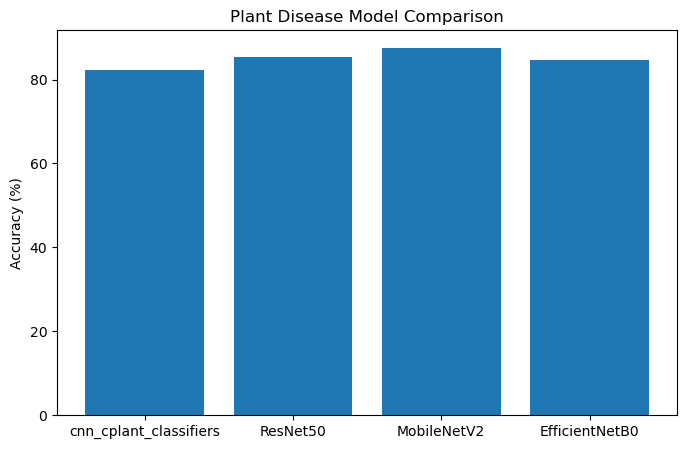

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"],comparison["Accuracy"])
plt.ylabel("Accuracy (%)")
plt.title("Plant Disease Model Comparison")

plt.show()

In [25]:
# Recover class names

try:
    classes = train_loader.dataset.dataset.classes
except:
    classes = full_dataset.classes

print(
"Total Classes:",
len(classes)
)

print(
classes[:5]
)

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


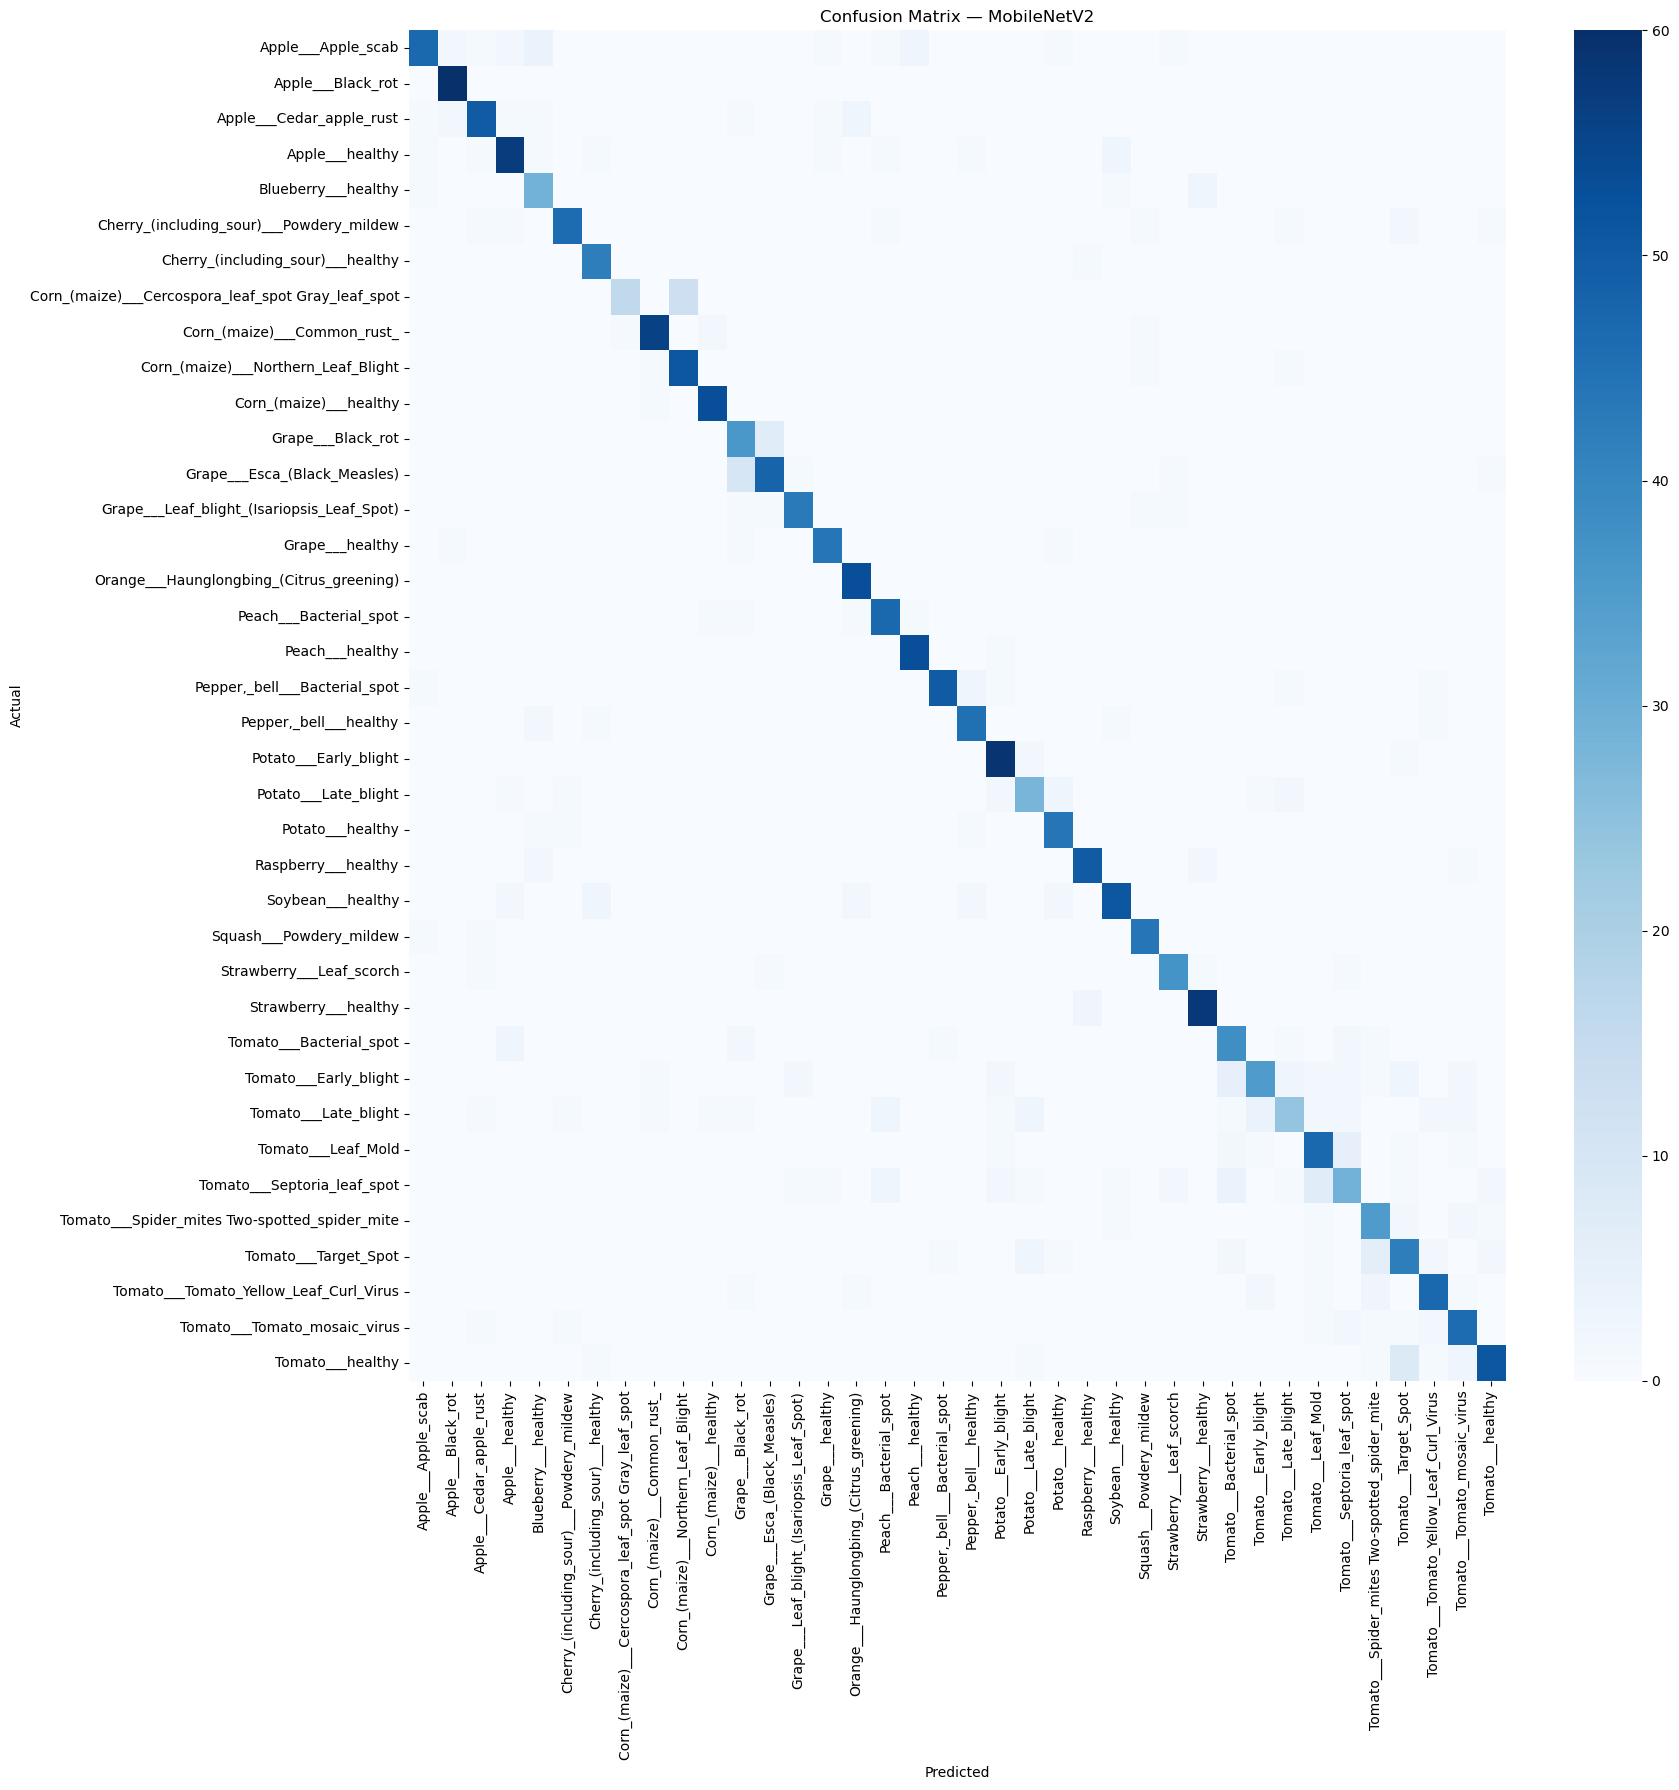

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
model.eval()
pred = []
true = []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)
        output = model(x)
        prediction = output.argmax(dim=1)
        pred.extend(prediction.cpu().numpy())
        true.extend( y.cpu().numpy())

# Create matrix
cm = confusion_matrix(
    true,
    pred
)

# Plot
plt.figure( figsize=(18,18))

sns.heatmap( cm, cmap="Blues", xticklabels=classes,yticklabels=classes)
plt.title("Confusion Matrix — MobileNetV2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [27]:
from sklearn.metrics import classification_report
print(
classification_report(
true,
pred,
target_names=classes,
zero_division=0
)

)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.90      0.75      0.82        63
                                 Apple___Black_rot       0.92      1.00      0.96        60
                          Apple___Cedar_apple_rust       0.88      0.83      0.85        60
                                   Apple___healthy       0.85      0.85      0.85        67
                               Blueberry___healthy       0.72      0.85      0.78        34
          Cherry_(including_sour)___Powdery_mildew       0.92      0.85      0.88        54
                 Cherry_(including_sour)___healthy       0.88      0.98      0.92        43
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.55      0.70        29
                       Corn_(maize)___Common_rust_       0.93      0.93      0.93        60
               Corn_(maize)___Northern_Leaf_Blight       0.80      0.94      0.

In [30]:
import numpy as np

np.save("plant_classes.npy",classes)

In [31]:
torch.save(
model.state_dict(),
"mobilenet_plant.pth"
)

In [33]:
torch.save({

"model_state_dict":
model.state_dict(),

"class_names":
classes

},

"cnn_cplant_classifiers.pth"
)

In [1]:
import torch

MODEL_PATH = r"C:\Users\Komal\OneDrive\Desktop\plant_disease\code\mobilenet_plant.pth"

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu"
)

print(checkpoint.keys())

odict_keys(['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.0.block.0.0.weight', 'features.1.0.block.0.1.weight', 'features.1.0.block.0.1.bias', 'features.1.0.block.0.1.running_mean', 'features.1.0.block.0.1.running_var', 'features.1.0.block.0.1.num_batches_tracked', 'features.1.0.block.1.fc1.weight', 'features.1.0.block.1.fc1.bias', 'features.1.0.block.1.fc2.weight', 'features.1.0.block.1.fc2.bias', 'features.1.0.block.2.0.weight', 'features.1.0.block.2.1.weight', 'features.1.0.block.2.1.bias', 'features.1.0.block.2.1.running_mean', 'features.1.0.block.2.1.running_var', 'features.1.0.block.2.1.num_batches_tracked', 'features.2.0.block.0.0.weight', 'features.2.0.block.0.1.weight', 'features.2.0.block.0.1.bias', 'features.2.0.block.0.1.running_mean', 'features.2.0.block.0.1.running_var', 'features.2.0.block.0.1.num_batches_tracked', 'features.2.0.block.1.0.weight',

A comparative analysis was conducted using four deep learning models for plant disease classification: Custom CNN, ResNet50, MobileNetV2, and EfficientNetB0. The models were evaluated using validation accuracy as the primary metric, along with precision, recall, and F1-score to measure classification performance.

Among all models, MobileNetV2 achieved the highest validation accuracy of 87.4%, outperforming Custom CNN (82.25%), ResNet50 (85.4%), and EfficientNetB0 (84.65%). The Custom CNN provided a strong baseline and demonstrated effective feature learning, while the pretrained models showed improved generalization through transfer learning.

MobileNetV2 delivered the best balance between classification accuracy, computational efficiency, model size, and inference speed, making it the most suitable model for deployment in the final application. Based on these results, MobileNetV2 was selected as the final model for integration into the Streamlit-based plant disease detection system